In [9]:
import numpy as np

left_outputs = np.load("/workspace/data/sam3d_body_results/person/run_3/left/frame_0000_sam_3d_body_outputs.npz", allow_pickle=True)
right_outputs = np.load("/workspace/data/sam3d_body_results/person/run_3/right/frame_0000_sam_3d_body_outputs.npz", allow_pickle=True)

# left_outputs = np.load("/workspace/data/sam3d_body_results/unity/male/left_sam_3d_body_outputs.npz", allow_pickle=True)['arr_0']
# right_outputs = np.load("/workspace/data/sam3d_body_results/unity/male/right_sam_3d_body_outputs.npz", allow_pickle=True)['arr_0']

In [2]:
for k, v in left_outputs.items():
	if isinstance(v, np.ndarray):
		print(k, v.shape)
	elif v is None:
		print(k, v)

bbox (4,)
focal_length ()
pred_keypoints_3d (70, 3)
pred_keypoints_2d (70, 2)
pred_vertices (18439, 3)
pred_cam_t (3,)
pred_pose_raw (266,)
global_rot (3,)
body_pose_params (133,)
hand_pose_params (108,)
scale_params (28,)
shape_params (45,)
expr_params (72,)
mask ()
pred_joint_coords (127, 3)
pred_global_rots (127, 3, 3)
lhand_bbox (4,)
rhand_bbox (4,)
frame (1080, 1920, 3)
frame_idx ()


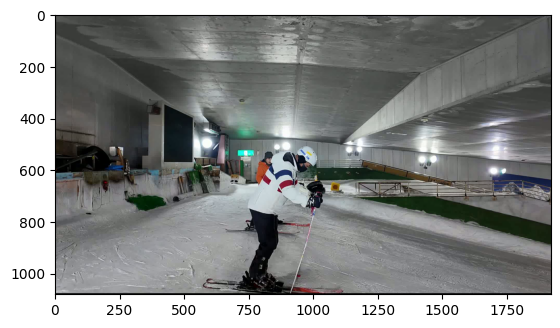

In [3]:
# draw left and right 3d pose in one plot 
import matplotlib.pyplot as plt

frame = right_outputs['frame']


plt.imshow(frame)


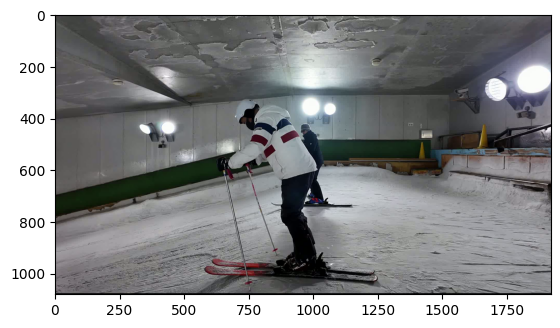

In [4]:
left_frame = left_outputs['frame']
plt.imshow(left_frame)

In [5]:
keypoints_3d = one_sample["pred_keypoints_3d"]

print(keypoints_3d.shape)
fig_3d = visualizer.draw_skeleton_3d(ax=None, points_3d=keypoints_3d)

fig_3d.show()

NameError: name 'one_sample' is not defined

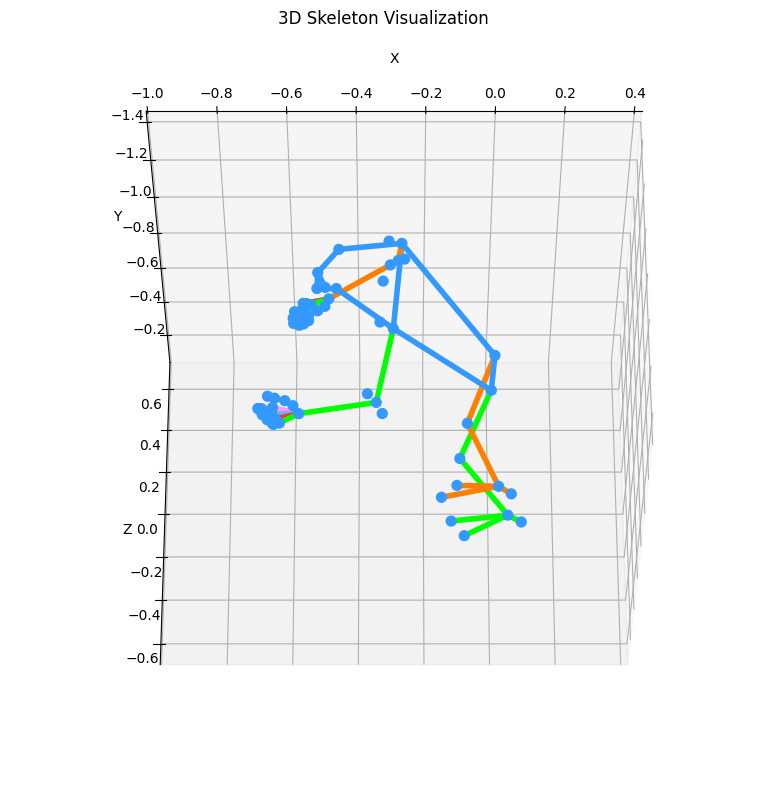

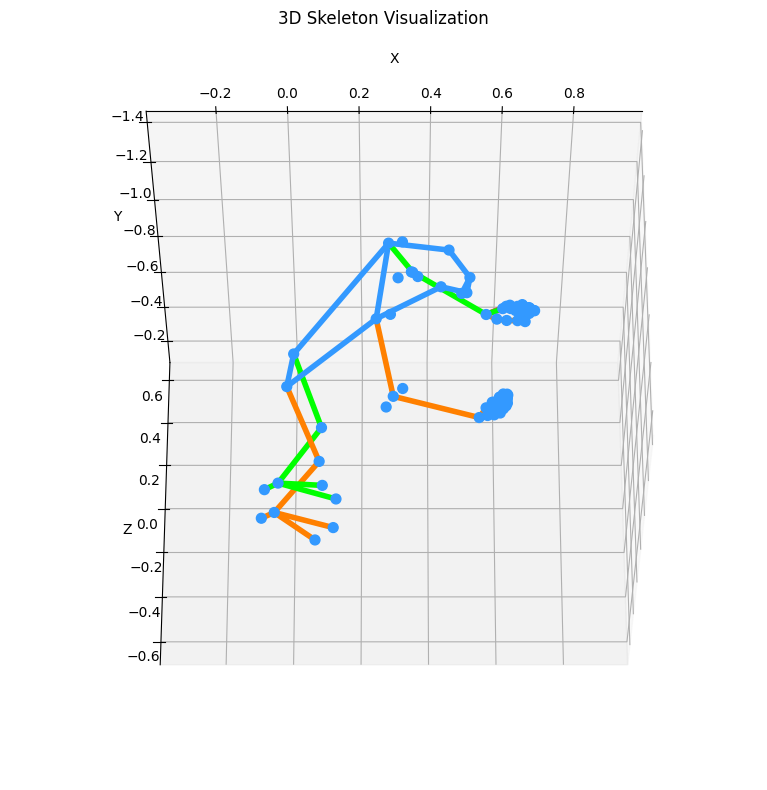

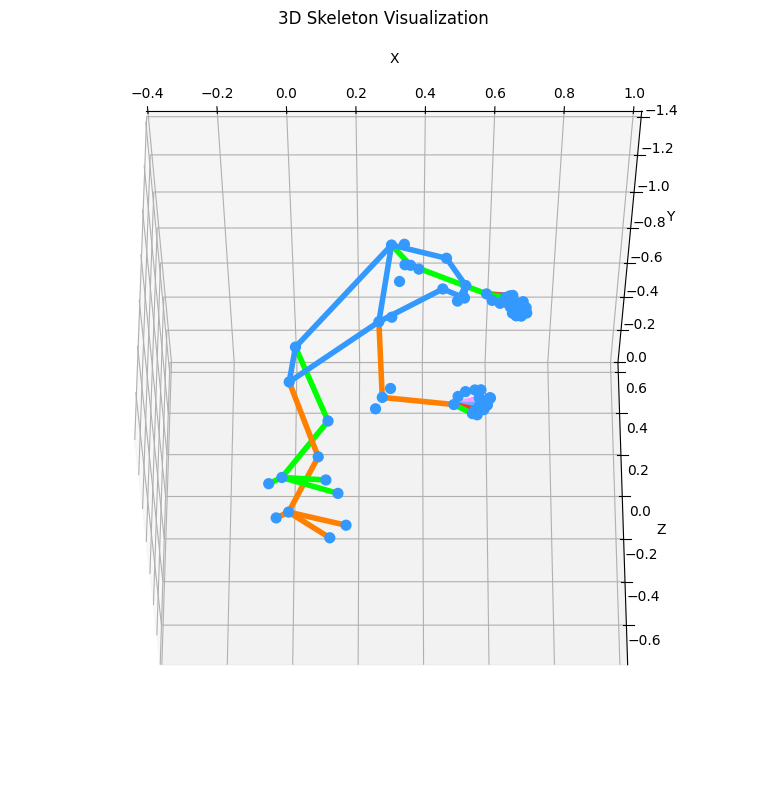

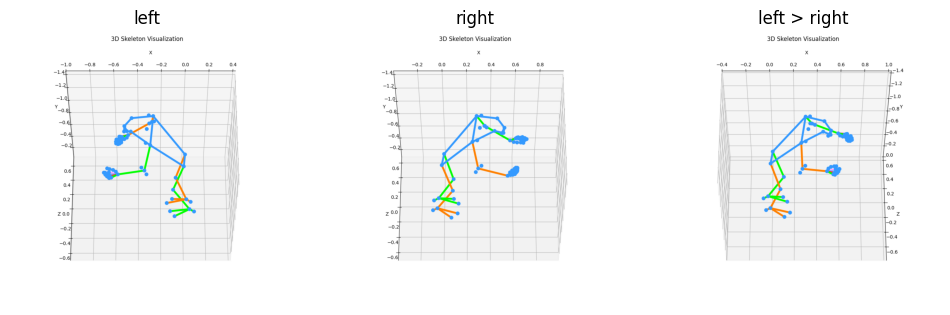

In [ ]:
# Visualization of 3D point set alignment with Kabsch (SVD) in NumPy

import numpy as np
import matplotlib.pyplot as plt

# ---------- 2) Helper: rigid transform via SVD (Kabsch) ----------
def rigid_transform_3D(targetr, source):

    assert targetr.shape == source.shape and targetr.shape[1] == 3

    centroid_A = np.mean(targetr, axis=0)
    centroid_B = np.mean(source, axis=0)

    AA = targetr - centroid_A
    BB = source - centroid_B

    H = BB.T @ AA
    U, S, Vt = np.linalg.svd(H)
    R = Vt.T @ U.T

    if np.linalg.det(R) < 0:
        Vt[-1, :] *= -1
        R = Vt.T @ U.T

    t = centroid_B - R @ centroid_A
    return R, t

# =========================================================================
# 3) 创建合成示例 (模拟 sam3d_body 的 3D 关键点输入)
# =========================================================================

# 模拟 Ground Truth (Target B)
Lt_n = left_outputs[0]['pred_keypoints_3d']  # 使用左侧关键点作为目标 B
Rt_n = right_outputs[0]['pred_keypoints_3d']  # 使用右侧关键点作为源 A

# print("left_outputs")
# print(left_outputs[0]['pred_cam_t'])
# print(left_outputs[0]['pred_global_rots'])

# print("right_outputs")
# print(right_outputs[0]['pred_cam_t'])
# print(right_outputs[0]['pred_global_rots'])

# ---------- 4) 恢复变换并对齐 ----------
# 将 Source A (Lt_n) 对齐到 Target B (Rt_n)
R, t = rigid_transform_3D(targetr=Rt_n, source=Lt_n)
# print("Rigid Transform:")
# print(R, t)
A_aligned = (Lt_n @ R.T) + t

# 计算对齐误差 (RMSE)
rmse = np.sqrt(np.mean(np.sum((A_aligned - Rt_n)**2, axis=1)))


# Plot BEFORE alignment
fig1 = visualizer.draw_skeleton_3d(ax=None, points_3d=Lt_n)

fig2 = visualizer.draw_skeleton_3d(ax=None, points_3d=Rt_n)

# Plot AFTER alignment
fig3 = visualizer.draw_skeleton_3d(ax=None, points_3d=A_aligned)

def fig_to_array(fig):
    """把 matplotlib Figure 转成 numpy 数组 (RGBA)"""
    fig.canvas.draw()
    data = np.array(fig.canvas.renderer.buffer_rgba())
    return data

# 假设你已有 fig1, fig2, fig3
img1 = fig_to_array(fig1)
img2 = fig_to_array(fig2)
img3 = fig_to_array(fig3)

# 在一个总的 fig 里排成一行三列
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, img, title in zip(axes, [img1, img2, img3], ["left", "right", "left > right"]):
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(title)

fig.show()


In [ ]:

# ============================================================
# 左右视角统一坐标系 → 融合关键点 → 显示融合骨架 + 两相机位置 + 相机坐标轴
# （修正版：先自动把 kpts 统一到 camera frame）
# ============================================================

import cv2
import numpy as np
import plotly.graph_objects as go

frame_idx = 0

out_L = left_outputs[frame_idx]
out_R = right_outputs[frame_idx]

# ---- 0. helper: 自动统一到 camera frame ----
def to_camera_frame(kpts_raw: np.ndarray, pred_cam_t: np.ndarray):
    """
    返回：kpts_cam, mode
    mode=already camera-frame 或 pelvis-frame -> camera-frame (+pred_cam_t)
    """
    root_raw = kpts_raw[0]
    d_raw = float(np.linalg.norm(root_raw - pred_cam_t))
    d_plus = float(np.linalg.norm((root_raw + pred_cam_t) - pred_cam_t))

    if d_raw <= d_plus:
        return kpts_raw, 'already camera-frame'
    return kpts_raw + pred_cam_t, 'pelvis-frame -> camera-frame (+pred_cam_t)'

# ---- 1. cam frame → body frame ----
R_L = axisangle_to_rotmat(out_L['global_rot'])       # body→cam (left)
R_R = axisangle_to_rotmat(out_R['global_rot'])       # body→cam (right)
t_L = out_L['pred_cam_t'].astype(np.float32)
t_R = out_R['pred_cam_t'].astype(np.float32)

kpts_L_raw = out_L['pred_keypoints_3d'].astype(np.float32)
kpts_R_raw = out_R['pred_keypoints_3d'].astype(np.float32)

kpts_L_cam, mode_L = to_camera_frame(kpts_L_raw, t_L)
kpts_R_cam, mode_R = to_camera_frame(kpts_R_raw, t_R)

print(f"[L] {mode_L}")
print(f"[R] {mode_R}")

# X_body = (X_cam - t) @ R
kpts_L_body = (kpts_L_cam - t_L) @ R_L
kpts_R_body = (kpts_R_cam - t_R) @ R_R

C_L_in_L = (-t_L) @ R_L
C_R_in_R = (-t_R) @ R_R

# ---- 2. Kabsch: right_body → left_body ----
R_align, t_align = rigid_transform_3D(targetr=kpts_L_body, source=kpts_R_body)

kpts_R_aligned = kpts_R_body @ R_align.T + t_align
C_R_in_L = C_R_in_R @ R_align.T + t_align

rmse_after = float(np.sqrt(np.mean(np.sum((kpts_R_aligned - kpts_L_body)**2, axis=1))))
print(f"Alignment RMSE after: {rmse_after:.4f} m")
print(f"C_L  in left body frame : {C_L_in_L}")
print(f"C_R  in left body frame : {C_R_in_L}")
print(f"Cam-to-Cam distance     : {np.linalg.norm(C_L_in_L - C_R_in_L):.4f} m")

# ---- 3. 融合关键点 ----
kpts_fused = (kpts_L_body + kpts_R_aligned) / 2.0

# ---- 4. 计算相机坐标轴（在左体坐标系下） ----
# R 是 body→cam，所以 cam 轴 i 在 body frame 中 = R.T[:, i]
def cam_axes_in_left_body(R_cam, R_align=None):
    axes = R_cam.T
    axes = axes.T
    if R_align is not None:
        axes = axes @ R_align.T
    return axes

axes_L = cam_axes_in_left_body(R_L)
axes_R = cam_axes_in_left_body(R_R, R_align)

# ---- 5. Plotly 可视化 ----
SKEL = visualizer.skeleton
AXIS_SCALE = 0.3
AXIS_COLORS = ['red', 'lime', 'blue']
AXIS_NAMES = ['X', 'Y', 'Z']

def add_skel_trace(fig, kpts, color, name):
    fig.add_trace(go.Scatter3d(
        x=kpts[:, 0], y=kpts[:, 1], z=kpts[:, 2],
        mode='markers', marker=dict(size=4, color=color, opacity=0.85),
        name=name,
    ))
    for i, (a, b) in enumerate(SKEL):
        if a < len(kpts) and b < len(kpts):
            fig.add_trace(go.Scatter3d(
                x=[kpts[a, 0], kpts[b, 0], None],
                y=[kpts[a, 1], kpts[b, 1], None],
                z=[kpts[a, 2], kpts[b, 2], None],
                mode='lines', line=dict(color=color, width=2),
                legendgroup=name, showlegend=(i == 0),
            ))

def add_camera_frame(fig, center, axes, cam_name, scale=AXIS_SCALE):
    fig.add_trace(go.Scatter3d(
        x=[center[0]], y=[center[1]], z=[center[2]],
        mode='markers+text',
        marker=dict(size=10, symbol='diamond', color='black'),
        text=[cam_name], textposition='top center',
        name=cam_name,
    ))
    for axis_vec, color, aname in zip(axes, AXIS_COLORS, AXIS_NAMES):
        tip = center + axis_vec * scale
        fig.add_trace(go.Scatter3d(
            x=[center[0], tip[0]],
            y=[center[1], tip[1]],
            z=[center[2], tip[2]],
            mode='lines+text',
            line=dict(color=color, width=4),
            text=[None, f'{cam_name}-{aname}'],
            textposition='top center',
            legendgroup=cam_name,
            showlegend=False,
        ))
    pelvis = kpts_fused[0]
    fig.add_trace(go.Scatter3d(
        x=[center[0], pelvis[0]], y=[center[1], pelvis[1]], z=[center[2], pelvis[2]],
        mode='lines', line=dict(color='gray', width=1, dash='dash'),
        showlegend=False,
    ))

fig = go.Figure()

add_skel_trace(fig, kpts_L_body, 'rgba(220,50,50,0.3)', 'Left  (body frame)')
add_skel_trace(fig, kpts_R_aligned, 'rgba(50,180,100,0.3)', 'Right -> left frame')

add_skel_trace(fig, kpts_fused, 'royalblue', 'Fused kpts (avg)')
fig.data[-1].marker.size = 6

fig.add_trace(go.Scatter3d(
    x=[0], y=[0], z=[0],
    mode='markers+text', marker=dict(size=8, color='black', symbol='x'),
    text=['pelvis_L'], textposition='top center', name='origin (left body)',
))

add_camera_frame(fig, C_L_in_L, axes_L, 'Cam_L')
add_camera_frame(fig, C_R_in_L, axes_R, 'Cam_R')

fig.update_layout(
    title=(
        f"Fused skeleton + Camera frames in left body frame "
        f"(frame={frame_idx}, RMSE={rmse_after:.4f}m) | "
        f"L:{mode_L} | R:{mode_R}"
    ),
    scene=dict(
        xaxis_title="X", yaxis_title="Y", zaxis_title="Z",
        aspectmode="data",
    ),
    width=950, height=750,
)
fig.show()


[L] pelvis-frame -> camera-frame (+pred_cam_t)
[R] pelvis-frame -> camera-frame (+pred_cam_t)
Alignment RMSE after: 0.7459 m
C_L  in left body frame : [ 2.3054664  -0.38634112  0.35652977]
C_R  in left body frame : [-1.6568097   0.93551666  2.3052053 ]
Cam-to-Cam distance     : 4.6092 m


In [ ]:
# ============================================================
# 左视角：自动判断 kpts 是否已在相机坐标系，再可视化
# 目标：避免相机原点与人体错误重叠
# ============================================================
import numpy as np
import plotly.graph_objects as go

frame_idx = 0
out_L = left_outputs[frame_idx]

kpts_raw = out_L['pred_keypoints_3d'].astype(np.float32)  # (J,3)
t_L = out_L['pred_cam_t'].astype(np.float32)              # pelvis in cam frame

# 经验判定：
# 如果 kpts[0] 更接近 pred_cam_t，则认为 kpts 已是相机系；
# 否则认为 kpts 是以骨盆为原点，需要 +pred_cam_t 才到相机系。
root_raw = kpts_raw[0]
d_raw = float(np.linalg.norm(root_raw - t_L))
d_plus = float(np.linalg.norm((root_raw + t_L) - t_L))

if d_raw <= d_plus:
    kpts_cam = kpts_raw
    mode = 'already camera-frame'
else:
    kpts_cam = kpts_raw + t_L
    mode = 'pelvis-frame -> camera-frame (+pred_cam_t)'

print(f'[Left] mode: {mode}')
print(f'[Left] ||root - pred_cam_t|| before={d_raw:.4f}, after_shift={d_plus:.4f}')
print(f'[Left] camera origin = [0, 0, 0], pelvis(pred_cam_t) = {t_L}')

cam_axes = np.eye(3)   # X, Y, Z in camera frame
AXIS_SCALE = 0.15
AXIS_COLORS = ['red', 'lime', 'blue']
AXIS_NAMES = ['X', 'Y', 'Z']
SKEL = visualizer.skeleton

fig = go.Figure()

# 关键点（统一到 camera frame 后）
fig.add_trace(go.Scatter3d(
    x=kpts_cam[:, 0], y=kpts_cam[:, 1], z=kpts_cam[:, 2],
    mode='markers', marker=dict(size=4, color='crimson'),
    name='kpts (camera frame)',
))

# 骨架连线
for i, (a, b) in enumerate(SKEL):
    if a < len(kpts_cam) and b < len(kpts_cam):
        fig.add_trace(go.Scatter3d(
            x=[kpts_cam[a, 0], kpts_cam[b, 0], None],
            y=[kpts_cam[a, 1], kpts_cam[b, 1], None],
            z=[kpts_cam[a, 2], kpts_cam[b, 2], None],
            mode='lines', line=dict(color='crimson', width=2),
            legendgroup='skel_L', showlegend=(i == 0), name='bones',
        ))

# pelvis 位置（相机系）
fig.add_trace(go.Scatter3d(
    x=[t_L[0]], y=[t_L[1]], z=[t_L[2]],
    mode='markers+text', marker=dict(size=8, color='black', symbol='x'),
    text=['pelvis (pred_cam_t)'], textposition='top center',
    name='pelvis',
))

# 相机原点
fig.add_trace(go.Scatter3d(
    x=[0], y=[0], z=[0],
    mode='markers+text', marker=dict(size=10, color='dodgerblue', symbol='diamond'),
    text=['Cam_L (origin)'], textposition='top center',
    name='camera origin',
))

# 相机坐标轴
for axis_vec, color, aname in zip(cam_axes, AXIS_COLORS, AXIS_NAMES):
    tip = axis_vec * AXIS_SCALE
    fig.add_trace(go.Scatter3d(
        x=[0, tip[0]], y=[0, tip[1]], z=[0, tip[2]],
        mode='lines+text', line=dict(color=color, width=4),
        text=[None, aname], textposition='top center',
        legendgroup='axes_L', showlegend=False,
    ))

fig.update_layout(
    title=(
        f'Left view in camera frame (frame={frame_idx}) | '
        f'{mode} | X=red Y=green Z=blue'
    ),
    scene=dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z', aspectmode='data'),
    width=920, height=720,
)
fig.show()


[Left] mode: pelvis-frame -> camera-frame (+pred_cam_t)
[Left] ||root - pred_cam_t|| before=3.1859, after_shift=1.4092
[Left] camera origin = [0, 0, 0], pelvis(pred_cam_t) = [-0.03981623  1.0632429   2.1117475 ]


In [ ]:
# ============================================================
# 右视角：自动判断 kpts 是否已在相机坐标系，再可视化
# ============================================================
import numpy as np
import plotly.graph_objects as go

frame_idx = 0
out_R = right_outputs[frame_idx]

kpts_raw = out_R['pred_keypoints_3d'].astype(np.float32)
t_R = out_R['pred_cam_t'].astype(np.float32)

root_raw = kpts_raw[0]
d_raw = float(np.linalg.norm(root_raw - t_R))
d_plus = float(np.linalg.norm((root_raw + t_R) - t_R))

if d_raw <= d_plus:
    kpts_cam = kpts_raw
    mode = 'already camera-frame'
else:
    kpts_cam = kpts_raw + t_R
    mode = 'pelvis-frame -> camera-frame (+pred_cam_t)'

print(f'[Right] mode: {mode}')
print(f'[Right] ||root - pred_cam_t|| before={d_raw:.4f}, after_shift={d_plus:.4f}')
print(f'[Right] camera origin = [0, 0, 0], pelvis(pred_cam_t) = {t_R}')

cam_axes = np.eye(3)
AXIS_SCALE = 0.15
AXIS_COLORS = ['red', 'lime', 'blue']
AXIS_NAMES = ['X', 'Y', 'Z']
SKEL = visualizer.skeleton

fig = go.Figure()

# 关键点（统一到 camera frame 后）
fig.add_trace(go.Scatter3d(
    x=kpts_cam[:, 0], y=kpts_cam[:, 1], z=kpts_cam[:, 2],
    mode='markers', marker=dict(size=4, color='seagreen'),
    name='kpts (camera frame)',
))

# 骨架连线
for i, (a, b) in enumerate(SKEL):
    if a < len(kpts_cam) and b < len(kpts_cam):
        fig.add_trace(go.Scatter3d(
            x=[kpts_cam[a, 0], kpts_cam[b, 0], None],
            y=[kpts_cam[a, 1], kpts_cam[b, 1], None],
            z=[kpts_cam[a, 2], kpts_cam[b, 2], None],
            mode='lines', line=dict(color='seagreen', width=2),
            legendgroup='skel_R', showlegend=(i == 0), name='bones',
        ))

# pelvis
fig.add_trace(go.Scatter3d(
    x=[t_R[0]], y=[t_R[1]], z=[t_R[2]],
    mode='markers+text', marker=dict(size=8, color='black', symbol='x'),
    text=['pelvis (pred_cam_t)'], textposition='top center',
    name='pelvis',
))

# camera origin
fig.add_trace(go.Scatter3d(
    x=[0], y=[0], z=[0],
    mode='markers+text', marker=dict(size=10, color='darkorange', symbol='diamond'),
    text=['Cam_R (origin)'], textposition='top center',
    name='camera origin',
))

# camera axes
for axis_vec, color, aname in zip(cam_axes, AXIS_COLORS, AXIS_NAMES):
    tip = axis_vec * AXIS_SCALE
    fig.add_trace(go.Scatter3d(
        x=[0, tip[0]], y=[0, tip[1]], z=[0, tip[2]],
        mode='lines+text', line=dict(color=color, width=4),
        text=[None, aname], textposition='top center',
        legendgroup='axes_R', showlegend=False,
    ))

fig.update_layout(
    title=(
        f'Right view in camera frame (frame={frame_idx}) | '
        f'{mode} | X=red Y=green Z=blue'
    ),
    scene=dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z', aspectmode='data'),
    width=920, height=720,
)
fig.show()


[Right] mode: pelvis-frame -> camera-frame (+pred_cam_t)
[Right] ||root - pred_cam_t|| before=4.2346, after_shift=1.4164
[Right] camera origin = [0, 0, 0], pelvis(pred_cam_t) = [-0.45446438  1.5032961   2.993183  ]


In [25]:
import numpy as np
import plotly.graph_objects as go

# ============================================================
# 以人物为中心计算相机位置，并按你定义的规则做坐标转换
# 你的坐标转换（SAM -> 目标坐标）:
#   x_t = -x_s
#   y_t = -z_s
#   z_t = -y_s
# ============================================================


def get_output_frame(loaded_npz, frame_idx=0):
    """兼容读取 npz 结构：直接字段 / outputs/output/arr_0 容器。"""
    if isinstance(loaded_npz, np.lib.npyio.NpzFile):
        files = set(loaded_npz.files)

        if "pred_keypoints_3d" in files and "pred_cam_t" in files:
            return {k: loaded_npz[k] for k in loaded_npz.files}

        key = None
        for cand in ["outputs", "output", "arr_0"]:
            if cand in files:
                key = cand
                break
        if key is None:
            raise KeyError(f"未找到可用字段。当前 keys: {sorted(files)}")

        obj = loaded_npz[key]
        if isinstance(obj, np.ndarray) and obj.dtype == object:
            if obj.ndim == 0:
                obj = obj.item()
            else:
                obj = obj[frame_idx]
                if isinstance(obj, np.ndarray) and obj.ndim == 0:
                    obj = obj.item()

        if isinstance(obj, list):
            obj = obj[frame_idx]

        if not isinstance(obj, dict):
            raise TypeError(f"容器解析后不是 dict，实际类型: {type(obj)}")

        return obj

    raise TypeError(f"不支持的 loaded_npz 类型: {type(loaded_npz)}")


def sam_to_target_axes(points: np.ndarray) -> np.ndarray:
    """支持 (3,) 或 (N,3) 的坐标映射。"""
    p = np.asarray(points, dtype=np.float32)
    if p.shape[-1] != 3:
        raise ValueError(f"输入最后一维必须是3，当前 shape={p.shape}")
    out = np.empty_like(p)
    
    out[..., 0] = p[..., 2]  # x_t = -x_s (但这里直接用 z_s 作为 x_t，后续可根据需要调整符号)
    out[..., 1] = p[..., 1]  # y_t = -z_s (但这里直接用 y_s 作为 y_t，后续可根据需要调整符号)
    out[..., 2] = -p[..., 0]  # z_t = -y_s (但这里直接用 -x_s 作为 z_t，后续可根据需要调整符号)
    return out


def to_camera_frame(kpts_raw: np.ndarray, pred_cam_t: np.ndarray):
    """自动判断并统一关键点到相机坐标系。"""
    root_raw = kpts_raw[0]
    d_raw = float(np.linalg.norm(root_raw - pred_cam_t))
    d_plus = float(np.linalg.norm((root_raw + pred_cam_t) - pred_cam_t))
    if d_raw <= d_plus:
        return kpts_raw, "already camera-frame"
    return kpts_raw + pred_cam_t, "pelvis-frame -> camera-frame (+pred_cam_t)"


frame_idx = 0
out_L = get_output_frame(left_outputs, frame_idx=frame_idx)
out_R = get_output_frame(right_outputs, frame_idx=frame_idx)

kpts_L_raw = out_L["pred_keypoints_3d"].astype(np.float32)
kpts_R_raw = out_R["pred_keypoints_3d"].astype(np.float32)
t_L = out_L["pred_cam_t"].astype(np.float32)
t_R = out_R["pred_cam_t"].astype(np.float32)

# 1) 先统一到相机坐标系

# 5) 简单可视化：人物中心=原点，显示左右骨架和相机位置（转换后坐标）
fig = go.Figure()

convert_kpts_L = sam_to_target_axes(kpts_L_raw)
convert_kpts_R = sam_to_target_axes(kpts_R_raw)


fig.add_trace(go.Scatter3d(
    x=convert_kpts_L[:, 0],
    y=convert_kpts_L[:, 1],
    z=convert_kpts_L[:, 2],
    mode="markers",
    marker=dict(size=4, color="royalblue"),
    name="Left kpts (person-centered, converted)",
))

fig.add_trace(go.Scatter3d(
    x=convert_kpts_R[:, 0],
    y=convert_kpts_R[:, 1],
    z=convert_kpts_R[:, 2],
    mode="markers",
    marker=dict(size=4, color="red"),
    name="Right kpts (person-centered, converted)",
))

fig.add_trace(go.Scatter3d(
    x=[0.0], y=[0.0], z=[0.0],
    mode="markers+text",
    marker=dict(size=8, color="black", symbol="x"),
    text=["person center"],
    textposition="top center",
    name="person center",
))
fig.update_layout(
    title="Person-centered camera position with custom axis conversion",
    scene=dict(xaxis_title="X", yaxis_title="Y", zaxis_title="Z", aspectmode="data"),
    width=920,
    height=720,
)
fig.show()
